# Data Visualization

In [1]:
# N_SAMPLES = 10000
N_SAMPLES = None
random_state = 11
fold_id = 0

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch


from src.data.io import load_data
from src.data.cleaning import process_data
from src.data.metadata import sequential_encoder, build_config



pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

print("Imports imported")


Imports imported


In [2]:
DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data path: {DATA_PATH}")

df_all = load_data(DATA_PATH)

df_processed = process_data(
    df_all,
    n_samples=N_SAMPLES,
    random_state=random_state,
    filters=None,
    require_duration=False,
    require_taxid=False,
    split_salts=False,
    remove_lone=False,
    remove_metals=False,
    max_conc_value=None,
    duration_fill_value=None,
    max_duration_hours=None,
    log_transform_duration=True,
    keep_duration_raw=True,
)

df_processed

Data path: /home/vollmers/gnn-thesis/Data/toxicity_all.csv
Filters
conc > 0
True: 1.000

Loaded and masked training data
Rows in full data: 561,100
Rows after mask: 561,100
Rows before preprocessing: 561,100
Rows after preprocessing:  561,100
Rows removed: 0


,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,conc,duration,duration_unit,effect,endpoint,SMILES,organism_lifestage,administration_route,species_sci_name,taxid,superkingdom,kingdom,phylum,subphylum,class,order,family,genus,species,species_group,log10c,duration_raw
0,RTECS7,mouse,Mus musculus,108073-64-9,"5H-Pyrrolo(2,1-c)(1,4)benzodiazepin-5-one, 1,2,3,10,11,11a-hexahydro-2-hydro...",mg/kg,36.200,NaN,h,MOR,EC50,COC1Nc2ccccc2C(=O)N2CC(O)CC12,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.558709,NaN
1,RTECS41,mouse,Mus musculus,78111-17-8,"Acanthifolicin, 9,10-deepithio-9,10-didehydro-",mg/kg,0.192,NaN,h,MOR,EC50,C=C1C(O)C2OC3(CCC(C=CC(C)C4CC(C)=CC5(OC(CC(C)(O)C(=O)O)CCC5O)O4)O3)CCC2OC1C(...,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,-0.716699,NaN
2,RTECS137,mouse,Mus musculus,4657-93-6,5-Acenaphthenamine,mg/kg,56.000,NaN,h,MOR,EC50,Nc1ccc2c3c(cccc13)CC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.748188,NaN
3,RTECS140,mouse,Mus musculus,102585-20-6,"5-Acenaphthenamine, 6,7,8,8a-tetrahydro-N-(2-oxazolin-2-yl)-",mg/kg,100.000,NaN,h,MOR,EC50,c1cc(NC2=NCCO2)c2c3c1CCC3CCC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,2.000000,NaN
4,RTECS141,rat,Rattus norvegicus,83-32-9,Acenaphthene,mg/kg,600.000,NaN,h,MOR,EC50,c1cc2c3c(cccc3c1)CC2,adult,fill,rattus norvegicus,10116,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10114.0,10116.0,rodents,2.778151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561095,AQTER1441956,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.041,2.283301,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-1.387216,192.0
561096,AQTER1441958,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0
561097,AQTER1441960,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.160,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.795880,96.0
561098,AQTER1441966,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0


In [ ]:
from src.data.simple_featurizer import simple_featurizer
from src.data.features_graph import GraphFeaturizer

ATOM_FEATURES = (
    "atomic_num",
    "degree",
    "formal_charge",
    "num_hs",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
    "atomic_mass",
    "period",
    "group",
    "covalent_radius",
    "vdw_radius",
    "is_metal",
)

BOND_FEATURES = (
    "bond_order",
    "is_conjugated",
    "is_in_ring",
    "stereo",
)

graph_featurizer = GraphFeaturizer(ATOM_FEATURES, BOND_FEATURES)

df_processed["features"] = df_processed["SMILES"].apply(graph_featurizer.featurize)

graph_cache = graph_featurizer.get_graph_cache()

from src.data.features_mol import add_molecule_metadata

MOLECULE_CATEGORICAL_COLS = [
    "is_salt",
    "has_metal",
    "is_single_node",
]

MOLECULE_NUMERICAL_COLS = [
    "fragment_count",
    # "mol_weight",
    "log10_mol_weight",
    # "logp",
    # "tpsa",
    # "log10_tpsa_plus1",
    # "h_bond_donor_count",
    # "h_bond_acceptor_count",
    # "heavy_atom_count",
    # "log10_heavy_atom_count_plus1",
    # "hetero_atom_count",
    # "halogen_count",
    # "metal_count",
    # "transition_metal_count",
    # "ring_count",
    # "aromatic_ring_count",
    # "rotatable_bond_count",
    "formal_charge",
]

# Add molecule-level metadata for categorical and numerical encoders
df_processed = add_molecule_metadata(df_processed, categorical_cols=MOLECULE_CATEGORICAL_COLS, numerical_cols=MOLECULE_NUMERICAL_COLS)

USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = PROJECT_ROOT / "Data" / "moredata" / "pretrained_tax_emb.pkl.zip"
print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

config_tax = {}

# Categorical encoding
exp_categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect"
]

CATEGORICAL_COLS = exp_categorical_cols + MOLECULE_CATEGORICAL_COLS

df_categorical = df_processed[CATEGORICAL_COLS].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, CATEGORICAL_COLS)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, CATEGORICAL_COLS)

species_group_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

NUMERICAL_COLS = ["duration"] + MOLECULE_NUMERICAL_COLS

/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


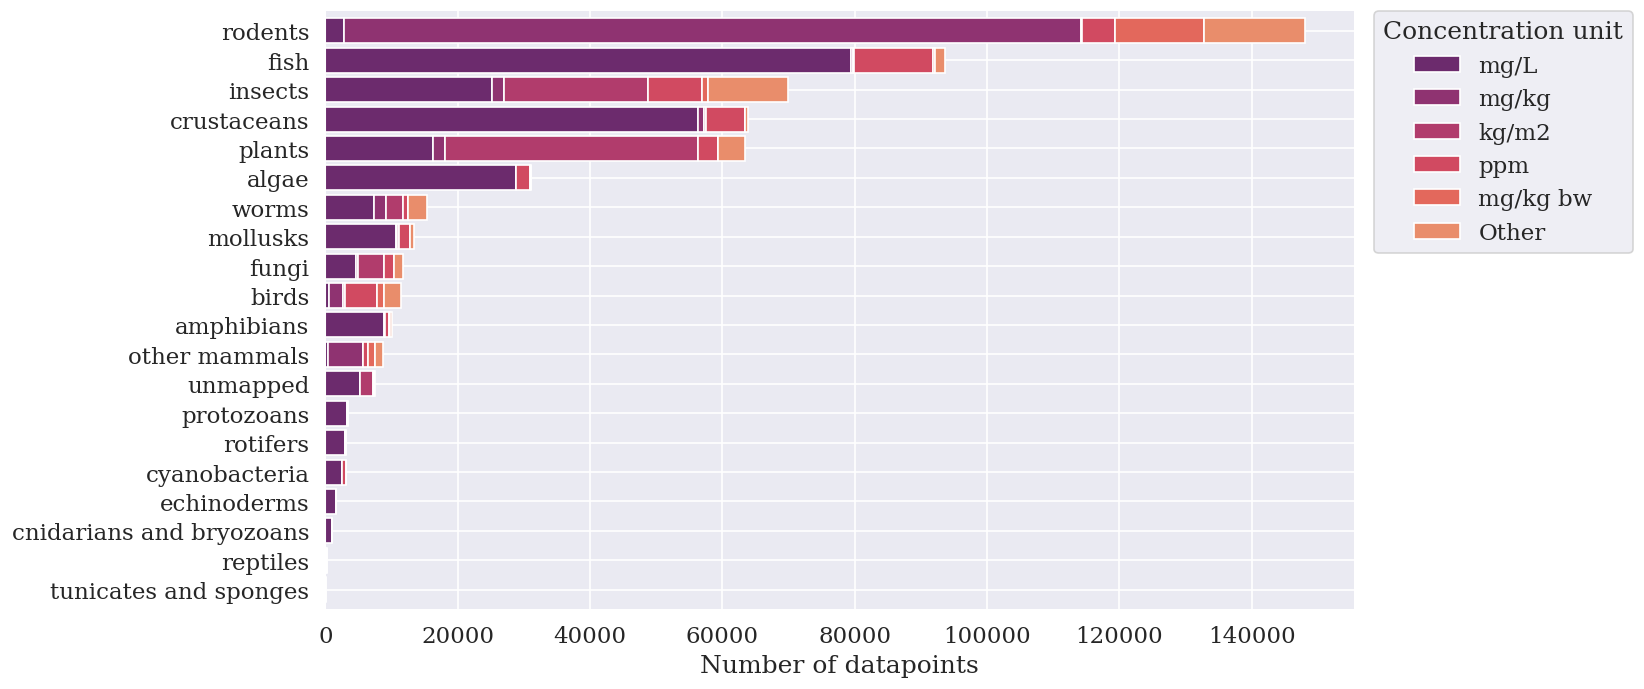

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize = (14, 6)

n_colors = 6
project_palette = sns.color_palette("flare_r", n_colors=n_colors)
cmap = sns.color_palette("flare_r", n_colors=n_colors, as_cmap=True)

# project_palette = ["#003f5c","#2f4b7c","#665191","#a05195","#d45087","#f95d6a","#ff7c43","#ffa600"]
# project_palette = ["#325771","#4c918f","#f8bd4f","#fd6735","#e42538","#f94e7b","#decfd0","#24272e"]


sns.set_theme(
    style="darkgrid",
    font="serif",
    # palette="flare_r",
    font_scale=1.25,
        rc={
        "text.usetex": False,   # important: do not use external LaTeX
        "font.family": "serif",
        "font.serif": [
            "CMU Serif",
            "Computer Modern Roman",
            "Latin Modern Roman",
            "DejaVu Serif"
        ],
        "mathtext.fontset": "cm",  # LaTeX-like math
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    },
    palette=project_palette
)

df = df_processed.copy()

# Order species groups by total count
species_order = df["species_group"].value_counts().index

# Keep top 5 concentration units, group the rest as Other
top_units = df["conc_unit"].value_counts().head(5).index

df["conc_unit_grouped"] = df["conc_unit"].where(
    df["conc_unit"].isin(top_units),
    "Other"
)

# Counts per species group and concentration unit
ct = pd.crosstab(
    df["species_group"],
    df["conc_unit_grouped"]
)

# Match species order, reversed because barh plots bottom-to-top
ct = ct.loc[species_order[::-1]]

# Put columns in desired order
unit_order = [u for u in top_units if u in ct.columns]
if "Other" in ct.columns:
    unit_order += ["Other"]

ct = ct[unit_order]

# Plot stacked count bars
ax = ct.plot(
    kind="barh",
    stacked=True,
    figsize=figsize,
    width=0.85,
    # color=sns.color_palette("flare_r", n_colors=len(unit_order))
)

ax.set_xlabel("Number of datapoints")
ax.set_ylabel("")
# ax.set_xscale("log")

ax.legend(
    title="Concentration unit",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2618174/1277231978.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


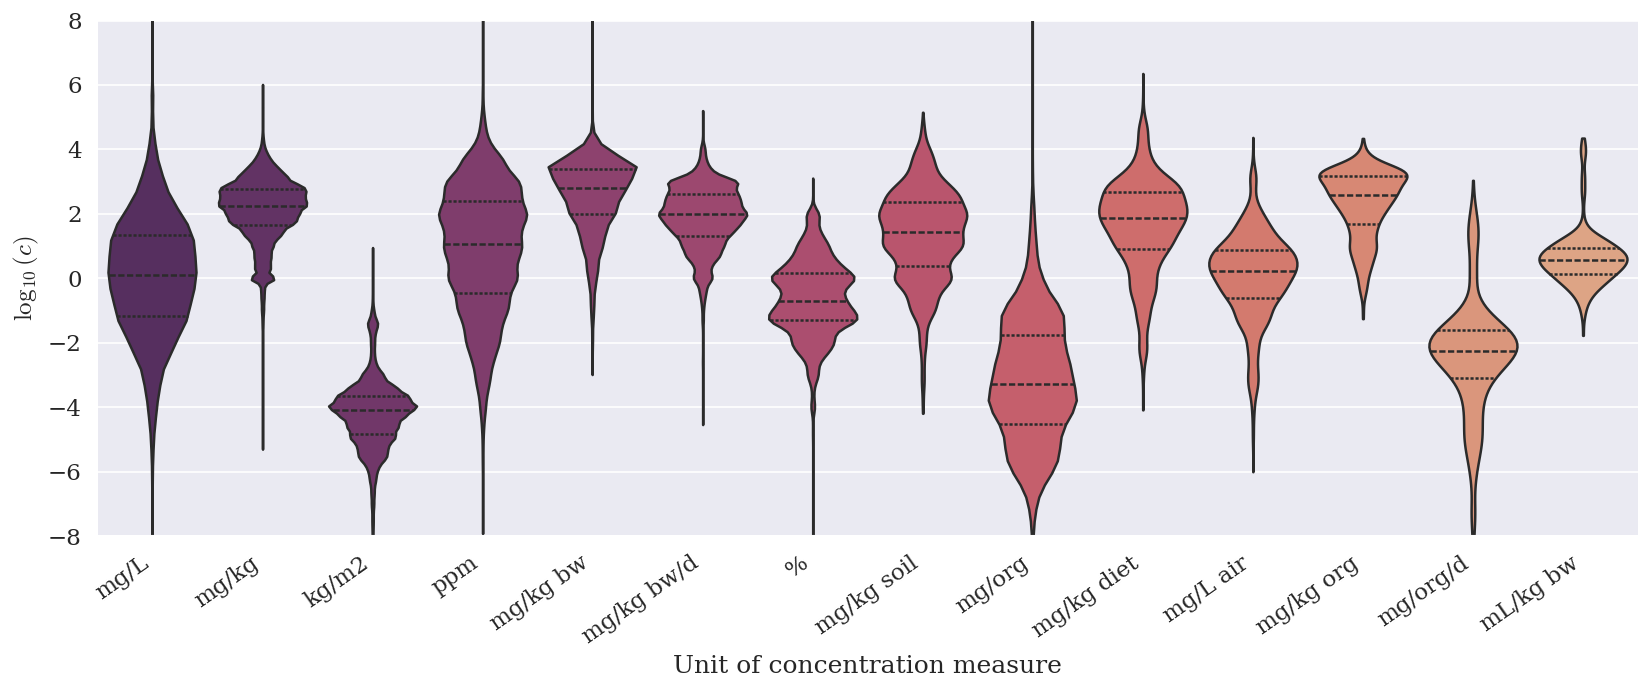

In [12]:
unit_order = df_processed["conc_unit"].value_counts().index.tolist()
n_units = len(unit_order)

fig, ax = plt.subplots(figsize=(14, 6))

n_colors = 14
project_palette = sns.color_palette("flare_r", n_colors=n_colors)
cmap = sns.color_palette("flare_r", n_colors=n_colors, as_cmap=True)

sns.violinplot(
    data=df,
    x="conc_unit",
    y="log10c",
    inner="quartile",
    order=unit_order,
    palette=project_palette,
    cut=0,
    linewidth=1.5,
    ax=ax
)

ax.set_ylim(-8, 8)

ax.set_xlabel("Unit of concentration measure")
ax.set_ylabel(r"$\log_{10}(c)$")
# ax.set_title("Distribution of toxicity concentrations by unit")

counts = df_processed["conc_unit"].value_counts()
ax.set_xticks(range(n_units))

# ax.set_xticklabels(
#     [f"{u}\n(n={counts[u]:,})" for u in unit_order],
# )


plt.xticks(rotation=35, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

## Model Architecture Mockup

In [ ]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = None
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").exists():
            PROJECT_ROOT = candidate
            break
    if PROJECT_ROOT is None:
        raise RuntimeError("Could not locate the project root.")

MODEL_SCHEMATIC_PATH = PROJECT_ROOT / "outputs" / "figures" / "model_architecture_mockup.pdf"
SAVE_MODEL_SCHEMATIC = True

schematic_palette = sns.color_palette("Greys", n_colors=6)
sns.set_theme(
    style="white",
    font="sans-serif",
    font_scale=1.25,
    rc={
        "text.usetex": False,
        "font.family": "sans-serif",
        "mathtext.fontset": "cm",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    },
    palette=schematic_palette,
)
ink = "#555555"
muted_ink = "#666666"
line_color = "#5c5c5c"
background = "white"
box_fill = "#f2f2f2"

colors = {
    "data": box_fill,
    "graph": box_fill,
    "meta": box_fill,
    "gnn": box_fill,
    "combine": box_fill,
    "predictor": box_fill,
    "output": box_fill,
}


def _add_box(ax, xy, width, height, title, lines=None, color="white", title_size=16, line_size=12):
    x, y = xy
    patch = mpatches.Rectangle(
        (x, y),
        width,
        height,
        linewidth=1.25,
        edgecolor=line_color,
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(
        x + 0.16,
        y + height - 0.28,
        title,
        ha="left",
        va="top",
        fontsize=title_size,
        fontweight="bold",
        color=ink,
    )
    if lines:
        line_step = min(0.42, (height - 0.62) / max(len(lines), 1))
        start_y = y + height - 0.72
        for i, line in enumerate(lines):
            ax.text(
                x + 0.16,
                start_y - i * line_step,
                line,
                ha="left",
                va="top",
                fontsize=line_size,
                color=ink,
            )
    return patch


def _add_arrow(ax, start, end, color=line_color, rad=0.0, lw=1.9):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=lw,
        color=color,
        shrinkA=8,
        shrinkB=8,
        connectionstyle=f"arc3,rad={rad}",
    )
    ax.add_patch(arrow)
    return arrow


fig, ax = plt.subplots(figsize=(14, 5.2))
fig.patch.set_facecolor(background)
ax.set_facecolor(background)
ax.set_xlim(0, 14)
ax.set_ylim(0, 5.4)
ax.axis("off")

# Raw inputs and preprocessing paths
ax.text(
    0.35,
    4.55,
    "Metadata\nSMILES",
    ha="left",
    va="top",
    fontsize=21,
    fontweight="bold",
    color=ink,
)
ax.text(
    2.55,
    4.55,
    "Preprocessing",
    ha="left",
    va="top",
    fontsize=18,
    color=ink,
)
_add_arrow(ax, (2.60, 4.12), (4.52, 4.12), lw=1.45)

_add_box(
    ax,
    (4.85, 3.42),
    2.38,
    1.48,
    "Metadata\nFeatures",
    color=colors["meta"],
    title_size=23,
)
_add_arrow(ax, (7.20, 4.12), (7.50, 4.12), lw=1.45)
_add_box(
    ax,
    (7.65, 3.32),
    2.00,
    1.62,
    "Meta\nEncoder",
    color=colors["meta"],
    title_size=22,
)
_add_arrow(ax, (9.62, 3.20), (10.02, 2.42), lw=1.45)

ax.text(
    1.78,
    2.94,
    "Graph featurizer",
    ha="left",
    va="center",
    fontsize=19,
    color=ink,
)
_add_arrow(ax, (1.02, 3.05), (1.98, 2.12), lw=1.45)
ax.text(
    2.40,
    2.05,
    "Graph\nObjects",
    ha="left",
    va="top",
    fontsize=23,
    fontweight="bold",
    color=ink,
)
_add_arrow(ax, (4.34, 1.60), (5.36, 1.60), lw=1.45)

_add_box(
    ax,
    (5.65, 0.40),
    3.38,
    2.10,
    "GNN",
    ["Fragment-aware", "Attention", "Recursive updates"],
    color=colors["gnn"],
    title_size=22,
    line_size=17,
)
_add_arrow(ax, (9.03, 1.48), (9.96, 1.48), lw=1.45)

_add_box(
    ax,
    (10.10, 0.72),
    1.84,
    1.58,
    "Final\nLayer",
    color=colors["predictor"],
    title_size=22,
)
_add_arrow(ax, (11.88, 2.38), (12.52, 3.08), lw=1.45)
ax.text(
    11.46,
    3.52,
    "Prediction",
    ha="left",
    va="center",
    fontsize=22,
    fontweight="bold",
    color=ink,
)
ax.text(
    12.72,
    3.05,
    r"$\log_{10}(c)$",
    ha="left",
    va="center",
    fontsize=18,
    color=ink,
)
if SAVE_MODEL_SCHEMATIC:
    MODEL_SCHEMATIC_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(MODEL_SCHEMATIC_PATH, bbox_inches="tight")

plt.show()
